# Laboratorio 5 - Naive Bayes 

Este notebook cubre los **diez incisos** del laboratorio, siguiendo una forma de trabajo parecida a la vista en clase:

1. Cargar y explorar los datos.
2. Preparar la variable `price`.
3. Separar `X` y `y`.
4. Hacer el `train/test split` igual al del laboratorio anterior.
5. Entrenar, predecir, evaluar y comparar.

## Ruta de trabajo

- Carga del conjunto de datos
- Limpieza de `price`
- Preparación del dataset para modelado
- Inciso 1: modelo de regresión con Naive Bayes
- Inciso 2: evaluación del modelo de regresión
- Inciso 3: comparación con regresión lineal y árbol de regresión
- Inciso 4: modelo de clasificación con categoría de precio
- Inciso 5: eficiencia del algoritmo para predecir y clasificar



In [1]:
%pip install pyreadr pandas scikit-learn matplotlib seaborn



   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
    --------------------------------------- 0.0/2.3 MB 281.8 kB/s eta 0:00:09
   - -------------------------------------- 0.1/2.3 MB 525.1 kB/s eta 0:00:05
   -- ------------------------------------- 0.2/2.3 MB 706.2 kB/s eta 0:00:04
   ---- ----------------------------------- 0.3/2.3 MB 1.1 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB 1.7 MB/s eta 0:00:02
   --------------- ------------------------ 0.9/2.3 MB 2.6 MB/s eta 0:00:01
   -------------------- ------------------- 1.2/2.3 MB 3.0 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------  2.3/2.3 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 4.7 MB/s eta 0:00:00
Note: you may need to resta


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%matplotlib inline

import warnings
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)



## Cargando y explorando el conjunto de datos

Comenzamos leyendo `listings.RData` y verificando el objeto principal con el que vamos a trabajar.



In [3]:
result = pyreadr.read_r("listings.RData")

print("Objetos encontrados en el RData:")
print(list(result.keys()))

df = result["listings"].copy()

print(f"Filas y columnas del dataset original: {df.shape}")
display(df.head())



Objetos encontrados en el RData:
['listings']
Filas y columnas del dataset original: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6

## Preparando la variable `price`

En este dataset el precio viene como texto (`$`, comas, espacios). Primero lo convertimos a numérico para poder modelarlo.



Filas originales: 171,748
Filas con precio disponible: 76,246
Filas eliminadas por no tener precio: 95,502


,price,price_num
0,$97.00,97.0
1,$160.00,160.0
2,$38.00,38.0
3,$145.00,145.0
4,$58.00,58.0


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
25%,120.000000
50%,193.000000
75%,326.000000
max,50123.000000


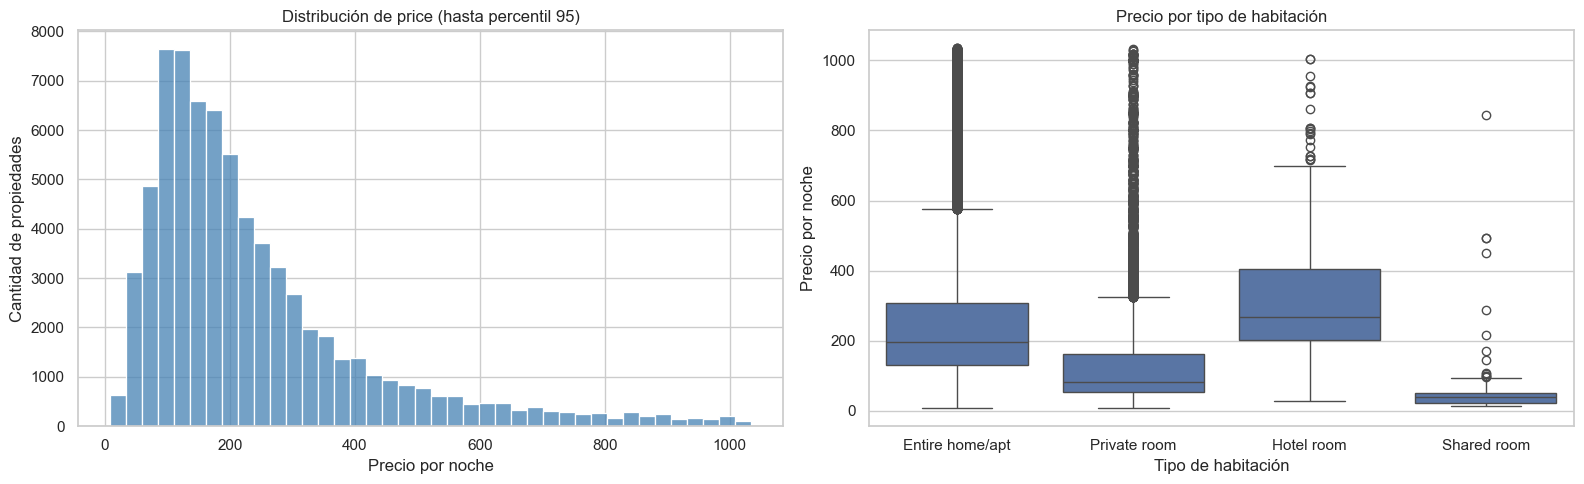

In [4]:
filas_antes = len(df)

df["price_num"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")

df = df.dropna(subset=["price_num"]).copy()
filas_despues = len(df)

print(f"Filas originales: {filas_antes:,}")
print(f"Filas con precio disponible: {filas_despues:,}")
print(f"Filas eliminadas por no tener precio: {filas_antes - filas_despues:,}")

display(df[["price", "price_num"]].head())
display(df["price_num"].describe().to_frame(name="price_num"))

limite_precio = df["price_num"].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=df.loc[df["price_num"] <= limite_precio],
    x="price_num",
    bins=40,
    color="steelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_title("Distribución de price (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")

if "room_type" in df.columns:
    room_order = df["room_type"].value_counts().head(4).index.tolist()
    box_df = df.loc[
        (df["price_num"] <= limite_precio) & (df["room_type"].isin(room_order)),
        ["room_type", "price_num"],
    ].copy()

    sns.boxplot(
        data=box_df,
        x="room_type",
        y="price_num",
        order=room_order,
        ax=axes[1],
    )
    axes[1].set_title("Precio por tipo de habitación")
    axes[1].set_xlabel("Tipo de habitación")
    axes[1].set_ylabel("Precio por noche")
else:
    sns.histplot(
        data=df.loc[df["price_num"] <= limite_precio],
        x="price_num",
        bins=30,
        color="salmon",
        edgecolor="white",
        ax=axes[1],
    )
    axes[1].set_title("Distribución alternativa de price")
    axes[1].set_xlabel("Precio por noche")
    axes[1].set_ylabel("Cantidad de propiedades")

plt.tight_layout()
plt.show()



## Preparando el dataset para modelado

Para que el modelo sea comparable y más limpio:

- quitamos identificadores, URLs, texto libre y fechas;
- eliminamos columnas con demasiados faltantes;
- convertimos columnas binarias y porcentajes;
- imputamos faltantes;
- y retiramos variables con posible fuga de información.



In [5]:
df_model = df.copy()

cols_drop = [
    "id",
    "listing_url",
    "scrape_id",
    "last_scraped",
    "source",
    "name",
    "description",
    "neighborhood_overview",
    "picture_url",
    "host_url",
    "host_name",
    "host_since",
    "host_location",
    "host_about",
    "host_thumbnail_url",
    "host_picture_url",
    "host_verifications",
    "neighbourhood",
    "calendar_updated",
    "calendar_last_scraped",
    "first_review",
    "last_review",
    "license",
    "bathrooms_text",
    "amenities",
    "avail_group",
]
cols_drop = [col for col in cols_drop if col in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

high_null = df_model.isnull().mean()
cols_high_null = high_null[high_null > 0.50].index.tolist()
df_model = df_model.drop(columns=cols_high_null).copy()

bool_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "has_availability",
    "instant_bookable",
]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = (
            df_model[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.strip()
        )
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

force_numeric = [
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "host_listings_count",
    "host_total_listings_count",
]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_columns_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_columns_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_columns_all] = df_model[numeric_columns_all].apply(
    pd.to_numeric,
    errors="coerce",
)
df_model[numeric_columns_all] = df_model[numeric_columns_all].fillna(
    df_model[numeric_columns_all].median()
)

for col in categorical_columns_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

excluded_features = [
    col
    for col in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
    if col in df_model.columns
]

X_model = df_model.drop(
    columns=["price", "price_num"] + excluded_features,
    errors="ignore",
)
y_price = df_model["price_num"].copy()

numerical_preview = selector(dtype_exclude=object)(X_model)
categorical_preview = selector(dtype_include=object)(X_model)

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Variables predictoras: {X_model.shape[1]}")
print(f"Columnas numéricas: {len(numerical_preview)}")
print(f"Columnas categóricas: {len(categorical_preview)}")
print(f"Columnas eliminadas por muchos faltantes: {len(cols_high_null)}")
print("Variables excluidas por posible fuga o identificación:")
print(["price", "price_num"] + excluded_features)



Filas disponibles para modelar: 76,246
Variables predictoras: 51
Columnas numéricas: 44
Columnas categóricas: 7
Columnas eliminadas por muchos faltantes: 0
Variables excluidas por posible fuga o identificación:
['price', 'price_num', 'host_id', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']


## Separando en train y test

El PDF pide que la comparación se haga bajo las mismas condiciones. Por eso aquí usamos el mismo criterio del laboratorio anterior:

- `70%` entrenamiento
- `30%` prueba
- `random_state = 42`



In [6]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X_model,
    y_price,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
)

numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print("=== Criterio de división ===")
print("Proporción: 70% entrenamiento / 30% prueba")
print(f"Train: {len(X_train):,} filas")
print(f"Test:  {len(X_test):,} filas")
print(f"Columnas numéricas: {len(numerical_columns)}")
print(f"Columnas categóricas: {len(categorical_columns)}")

display(pd.DataFrame({"train": y_train_price.describe(), "test": y_test_price.describe()}).round(2))



=== Criterio de división ===
Proporción: 70% entrenamiento / 30% prueba
Train: 53,372 filas
Test:  22,874 filas
Columnas numéricas: 44
Columnas categóricas: 7


,train,test
count,53372.00,22874.00
mean,747.00,758.69
std,4245.56,4262.44
min,8.00,9.00
25%,120.00,121.00
50%,192.00,194.00
75%,325.00,330.00
max,50123.00,50020.00


## Inciso 1 - Modelo de regresión con Naive Bayes

`scikit-learn` no trae un regresor de Naive Bayes como tal, así que usamos una aproximación razonable:

- discretizamos `price` en intervalos;
- discretizamos también las variables numéricas;
- codificamos las variables categóricas;
- entrenamos `CategoricalNB`;
- y recuperamos un precio numérico usando la mediana de cada intervalo.

No es una regresión exacta, pero sí permite construir un modelo compatible con la idea del laboratorio.



Intervalos usados para price: 5


,bin,min,median,max,count
0,0,8.0,80.0,107.0,10730
1,1,108.0,133.0,161.0,10744
2,2,162.0,193.0,233.0,10654
3,3,234.0,289.0,383.0,10609
4,4,384.0,626.0,50123.0,10635


,price_real,price_predicho,error_abs,caso
0,131.0,174.860996,43.860996,Caso 1
1,117.0,128.244047,11.244047,Caso 2
2,167.0,577.825693,410.825693,Caso 3
3,225.0,120.279597,104.720403,Caso 4
4,442.0,210.004739,231.995261,Caso 5
5,419.0,597.653474,178.653474,Caso 6
6,418.0,499.396032,81.396032,Caso 7
7,88.0,80.447705,7.552295,Caso 8
8,759.0,224.533750,534.466250,Caso 9
9,125.0,130.847811,5.847811,Caso 10


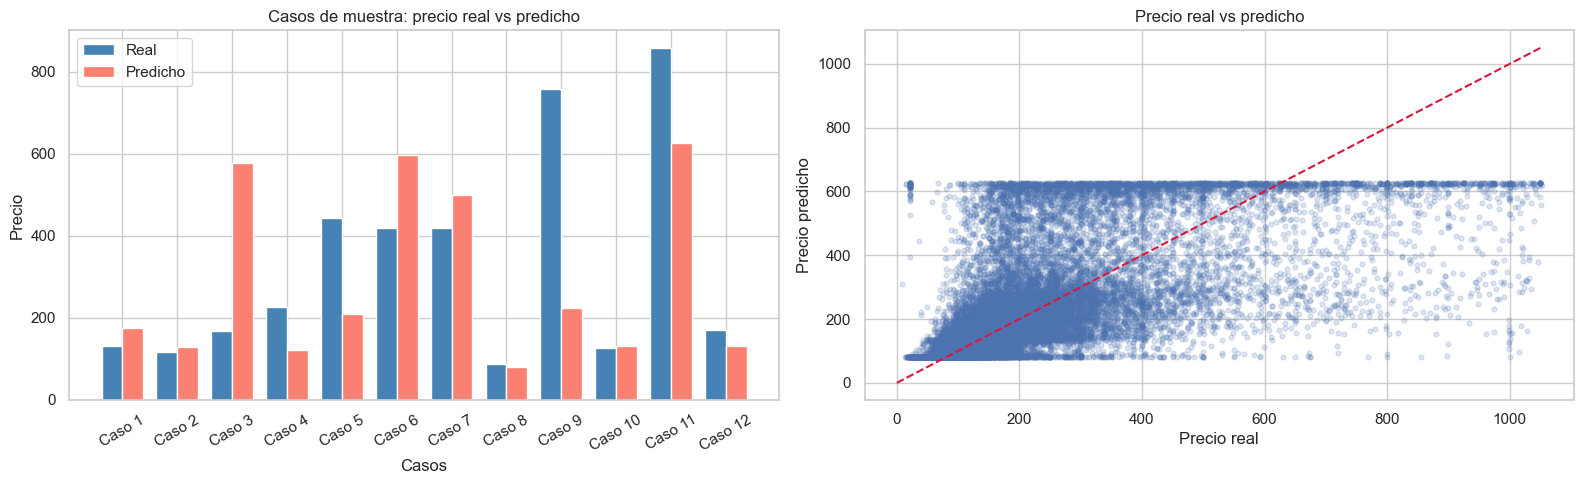

In [7]:
nb_regression_preprocessor = ColumnTransformer(
    [
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                ]
            ),
            categorical_columns,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=5,
                            encode="ordinal",
                            strategy="quantile",
                        ),
                    ),
                ]
            ),
            numerical_columns,
        ),
    ]
)

X_train_reg = np.clip(nb_regression_preprocessor.fit_transform(X_train), 0, None)
X_test_reg = np.clip(nb_regression_preprocessor.transform(X_test), 0, None)

y_train_price_bin = pd.qcut(
    y_train_price,
    q=5,
    labels=False,
    duplicates="drop",
)
y_train_price_bin = pd.Series(y_train_price_bin, index=y_train_price.index).astype(int)

bin_stats = (
    y_train_price.groupby(y_train_price_bin)
    .agg(["min", "median", "max", "count"])
    .reset_index()
)
bin_stats = bin_stats.rename(columns={bin_stats.columns[0]: "bin"})

regression_bin_medians = (
    y_train_price.groupby(y_train_price_bin)
    .median()
    .sort_index()
    .to_numpy(dtype=float)
)

nb_regressor = CategoricalNB()
nb_regressor.fit(X_train_reg, y_train_price_bin)

class_probabilities_reg = nb_regressor.predict_proba(X_test_reg)
y_pred_price = np.dot(class_probabilities_reg, regression_bin_medians)
y_pred_price = np.clip(y_pred_price, 0, None)

print(f"Intervalos usados para price: {y_train_price_bin.nunique()}")
display(bin_stats.round(2))

regression_preview = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
    }
)
regression_preview["error_abs"] = (
    regression_preview["price_real"] - regression_preview["price_predicho"]
).abs()

sample_preview = regression_preview.sample(12, random_state=42).reset_index(drop=True)
sample_preview["caso"] = [f"Caso {i + 1}" for i in range(len(sample_preview))]
display(sample_preview)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(sample_preview))
width = 0.38

axes[0].bar(
    x - width / 2,
    sample_preview["price_real"],
    width=width,
    label="Real",
    color="steelblue",
)
axes[0].bar(
    x + width / 2,
    sample_preview["price_predicho"],
    width=width,
    label="Predicho",
    color="salmon",
)
axes[0].set_title("Casos de muestra: precio real vs predicho")
axes[0].set_xlabel("Casos")
axes[0].set_ylabel("Precio")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sample_preview["caso"], rotation=30)
axes[0].legend()

limite_plot = regression_preview["price_real"].quantile(0.95)
mask_plot = regression_preview["price_real"] <= limite_plot

axes[1].scatter(
    regression_preview.loc[mask_plot, "price_real"],
    regression_preview.loc[mask_plot, "price_predicho"],
    alpha=0.18,
    s=12,
)
axes[1].plot([0, limite_plot], [0, limite_plot], color="crimson", linestyle="--")
axes[1].set_title("Precio real vs predicho")
axes[1].set_xlabel("Precio real")
axes[1].set_ylabel("Precio predicho")

plt.tight_layout()
plt.show()



## Inciso 2 - Evaluación del modelo de regresión

Como aquí queremos predecir una variable numérica, usamos métricas de regresión:

- `MAE`
- `RMSE`
- `R2`

Además, lo comparamos contra un baseline simple: predecir siempre la mediana del conjunto de entrenamiento.



,modelo,MAE,RMSE,R2
0,Naive Bayes Regresión,599.6036,4249.3773,0.0061
1,Baseline mediana,638.4534,4299.8510,-0.0177


,quintil,precio_real_medio,precio_predicho_medio,mae_promedio,conteo
0,"(8.999, 109.0]",76.79,114.46,41.62,4641
1,"(109.0, 164.0]",135.63,176.50,63.38,4543
2,"(164.0, 233.0]",195.82,250.95,103.16,4547
3,"(233.0, 388.0]",297.13,333.48,136.62,4569
4,"(388.0, 50020.0]",3089.99,485.16,2654.33,4574


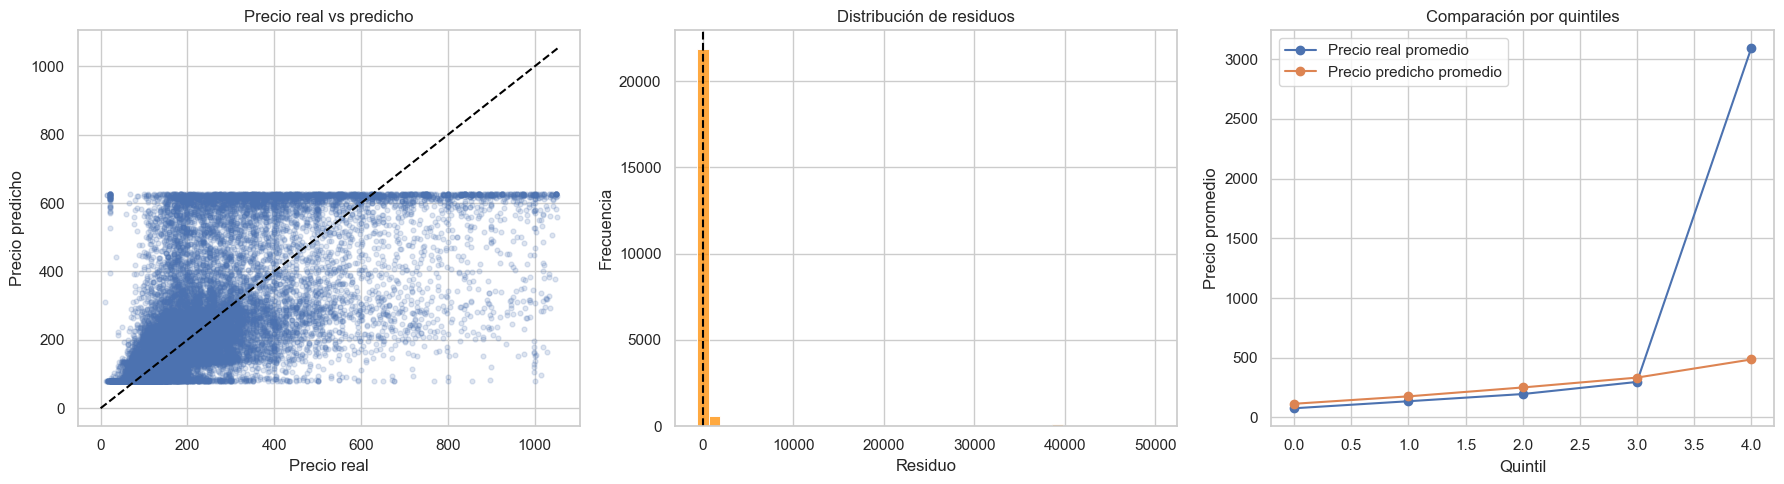

In [8]:
baseline_pred = np.repeat(y_train_price.median(), len(y_test_price))

metrics_df = pd.DataFrame(
    {
        "modelo": ["Naive Bayes Regresión", "Baseline mediana"],
        "MAE": [
            mean_absolute_error(y_test_price, y_pred_price),
            mean_absolute_error(y_test_price, baseline_pred),
        ],
        "RMSE": [
            mean_squared_error(y_test_price, y_pred_price) ** 0.5,
            mean_squared_error(y_test_price, baseline_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_test_price, y_pred_price),
            r2_score(y_test_price, baseline_pred),
        ],
    }
)

display(metrics_df.round(4))

eval_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
        "baseline": baseline_pred,
    }
)
eval_df["residuo"] = eval_df["price_real"] - eval_df["price_predicho"]
eval_df["error_abs"] = eval_df["residuo"].abs()

quintile_summary = (
    eval_df.assign(quintil=pd.qcut(eval_df["price_real"], q=5, duplicates="drop"))
    .groupby("quintil", observed=False)
    .agg(
        precio_real_medio=("price_real", "mean"),
        precio_predicho_medio=("price_predicho", "mean"),
        mae_promedio=("error_abs", "mean"),
        conteo=("price_real", "size"),
    )
    .reset_index()
)

display(quintile_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

limite_precio = eval_df["price_real"].quantile(0.95)
mask_plot = eval_df["price_real"] <= limite_precio

axes[0].scatter(
    eval_df.loc[mask_plot, "price_real"],
    eval_df.loc[mask_plot, "price_predicho"],
    alpha=0.18,
    s=12,
)
axes[0].plot([0, limite_precio], [0, limite_precio], color="black", linestyle="--")
axes[0].set_title("Precio real vs predicho")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")

sns.histplot(eval_df["residuo"], bins=40, color="darkorange", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")

axes[2].plot(
    quintile_summary["precio_real_medio"],
    label="Precio real promedio",
    marker="o",
)
axes[2].plot(
    quintile_summary["precio_predicho_medio"],
    label="Precio predicho promedio",
    marker="o",
)
axes[2].set_title("Comparación por quintiles")
axes[2].set_xlabel("Quintil")
axes[2].set_ylabel("Precio promedio")
axes[2].legend()

plt.tight_layout()
plt.show()



**Lectura rápida del inciso 2**

Aunque el modelo puede mejorar un poco al baseline, en regresión suele fallar bastante por varias razones estructurales:

- **Naive Bayes asume independencia entre variables**, pero en Airbnb muchas características están relacionadas entre sí: capacidad, número de camas, tipo de cuarto, ubicación y disponibilidad suelen moverse juntas.
- **El precio real no se modela directamente**, sino por intervalos. Eso obliga al algoritmo a aproximar cada caso con la mediana del grupo, lo que comprime mucho las predicciones.
- **Las propiedades caras y atípicas son difíciles de recuperar** porque, al discretizar, varios anuncios distintos terminan pareciéndose entre sí aunque en la realidad sus precios sean muy diferentes.
- **La distribución de `price` es muy asimétrica**, con cola larga y valores extremos. Eso hace que errores en propiedades premium castiguen mucho el `RMSE` y mantengan bajo el `R2`.
- Si en la gráfica de `precio real vs predicho` los puntos se concentran lejos de la diagonal, eso indica que el modelo no logra seguir bien la variabilidad real del precio.
- Si en los quintiles altos la curva predicha se aplana, entonces el problema principal no es solo error promedio: el modelo está perdiendo sensibilidad justo donde los precios más cambian.

En otras palabras, **Naive Bayes aquí funciona mejor como aproximación gruesa que como predictor fino de un valor exacto**. Sirve para capturar rangos generales de precio, pero no para estimar con precisión propiedades muy diferentes o de alto valor.



## Inciso 3 - Comparación con regresión lineal y árbol de regresión

Ahora usamos exactamente el mismo conjunto de entrenamiento y prueba para comparar:

- Naive Bayes
- Regresión lineal
- Árbol de regresión

Así la comparación sí es válida.



,modelo,MAE,RMSE,R2
0,Árbol de Regresión,210.4674,1714.4694,0.8382
1,Regresión Lineal,908.9650,3904.8916,0.1607
2,Naive Bayes Regresión,599.6036,4249.3773,0.0061


Mejor modelo según RMSE: Árbol de Regresión


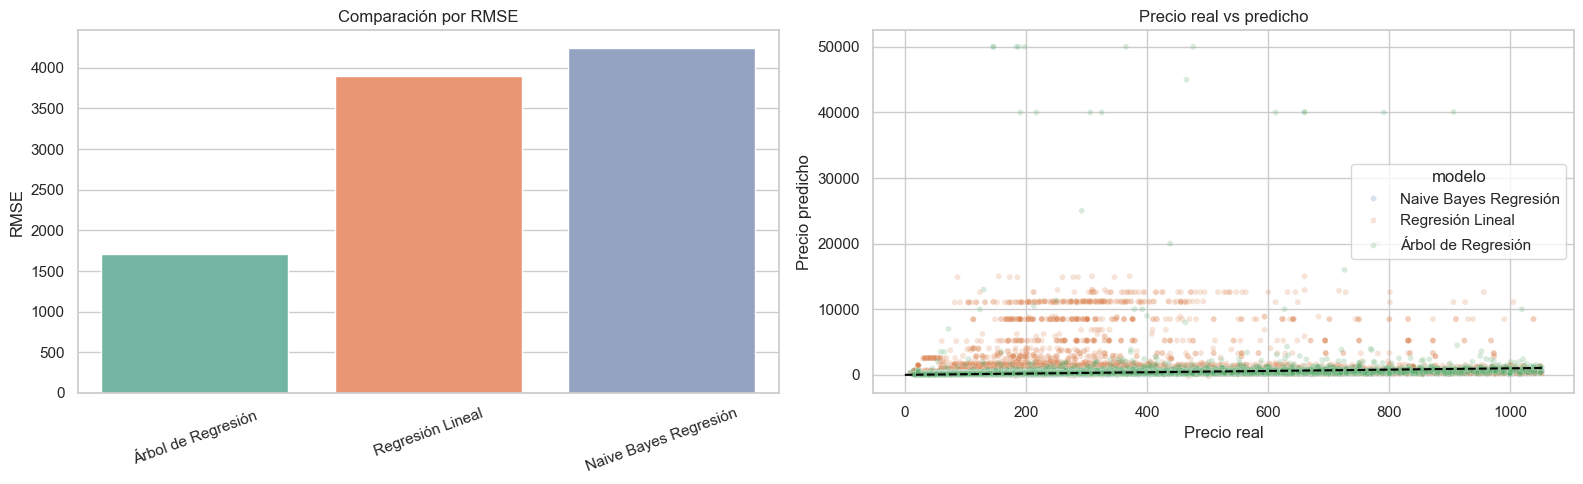

In [9]:
comparison_preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough",
)

pipeline_linear = Pipeline(
    [
        ("preprocessor", comparison_preprocessor),
        ("regressor", LinearRegression()),
    ]
)
pipeline_linear.fit(X_train, y_train_price)
y_pred_linear = pipeline_linear.predict(X_test)

pipeline_tree = Pipeline(
    [
        ("preprocessor", comparison_preprocessor),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=20,
                min_samples_leaf=1,
                min_samples_split=2,
            ),
        ),
    ]
)
pipeline_tree.fit(X_train, y_train_price)
y_pred_tree = pipeline_tree.predict(X_test)

comparison_df = pd.DataFrame(
    [
        {
            "modelo": "Naive Bayes Regresión",
            "MAE": mean_absolute_error(y_test_price, y_pred_price),
            "RMSE": mean_squared_error(y_test_price, y_pred_price) ** 0.5,
            "R2": r2_score(y_test_price, y_pred_price),
        },
        {
            "modelo": "Regresión Lineal",
            "MAE": mean_absolute_error(y_test_price, y_pred_linear),
            "RMSE": mean_squared_error(y_test_price, y_pred_linear) ** 0.5,
            "R2": r2_score(y_test_price, y_pred_linear),
        },
        {
            "modelo": "Árbol de Regresión",
            "MAE": mean_absolute_error(y_test_price, y_pred_tree),
            "RMSE": mean_squared_error(y_test_price, y_pred_tree) ** 0.5,
            "R2": r2_score(y_test_price, y_pred_tree),
        },
    ]
).sort_values("RMSE").reset_index(drop=True)

best_regression_model = comparison_df.loc[0, "modelo"]

display(comparison_df.round(4))
print(f"Mejor modelo según RMSE: {best_regression_model}")

comparison_predictions_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "Naive Bayes Regresión": y_pred_price,
        "Regresión Lineal": y_pred_linear,
        "Árbol de Regresión": y_pred_tree,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=comparison_df,
    x="modelo",
    y="RMSE",
    hue="modelo",
    dodge=False,
    legend=False,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Comparación por RMSE")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

limite_comp = comparison_predictions_df["price_real"].quantile(0.95)
plot_long = comparison_predictions_df.loc[
    comparison_predictions_df["price_real"] <= limite_comp
].melt(
    id_vars="price_real",
    var_name="modelo",
    value_name="price_predicho",
)
plot_long = plot_long[plot_long["modelo"] != "price_real"]

sns.scatterplot(
    data=plot_long,
    x="price_real",
    y="price_predicho",
    hue="modelo",
    alpha=0.22,
    s=18,
    ax=axes[1],
)
axes[1].plot([0, limite_comp], [0, limite_comp], color="black", linestyle="--")
axes[1].set_title("Precio real vs predicho")
axes[1].set_xlabel("Precio real")
axes[1].set_ylabel("Precio predicho")

plt.tight_layout()
plt.show()



**Lectura rápida del inciso 3**

Lo importante aquí no es solo ver cuál da mejores métricas, sino dejar claro que todos fueron comparados bajo las mismas condiciones. Esa es la parte clave del enunciado.



## Inciso 4 - Modelo de clasificación con categoría de precio

Para clasificar, construimos la variable categórica del precio en tres grupos:

- `barata`
- `media`
- `cara`

Los cortes se calculan **solo con el conjunto de entrenamiento**, para no filtrar información del test.



Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 268.00


,conteo
price_category,
barata,25414
media,25428
cara,25404


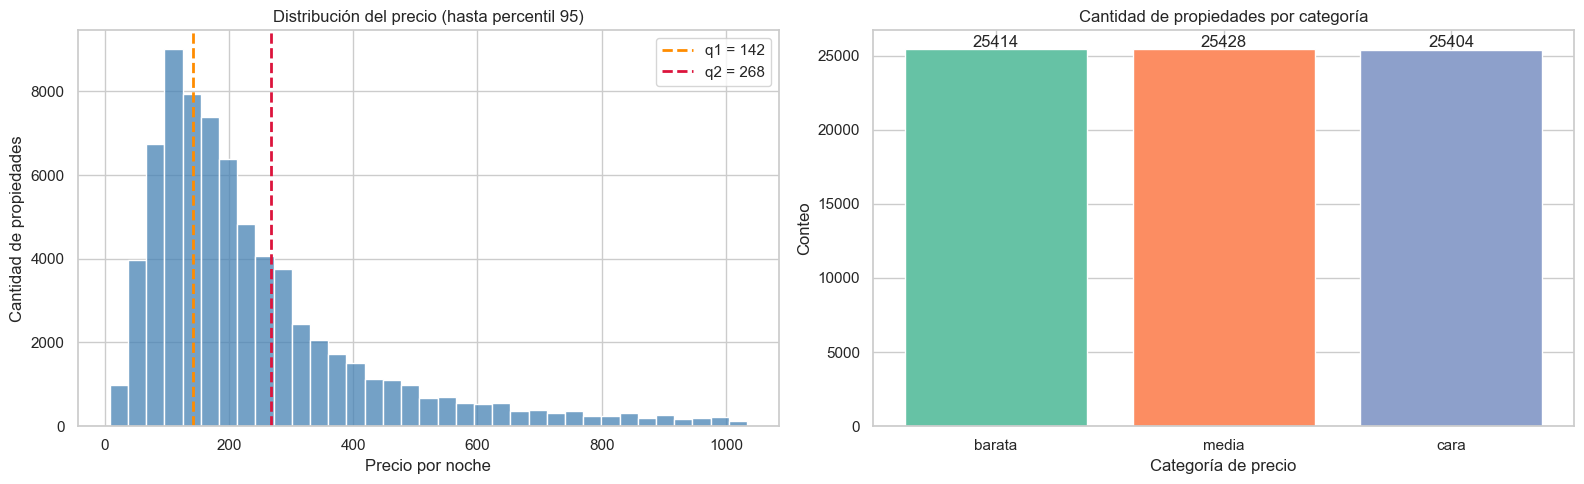

In [10]:
q1, q2 = y_train_price.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

y_train_class = pd.cut(
    y_train_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)
y_test_class = pd.cut(
    y_test_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

category_counts = (
    df_model["price_category"]
    .value_counts()
    .reindex(["barata", "media", "cara"])
)
display(category_counts.to_frame(name="conteo"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_plot_limit = df_model["price_num"].quantile(0.95)
price_plot_data = df_model.loc[df_model["price_num"] <= price_plot_limit, "price_num"]

sns.histplot(
    price_plot_data,
    bins=35,
    color="steelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(q1, color="darkorange", linestyle="--", linewidth=2, label=f"q1 = {q1:.0f}")
axes[0].axvline(q2, color="crimson", linestyle="--", linewidth=2, label=f"q2 = {q2:.0f}")
axes[0].set_title("Distribución del precio (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")
axes[0].legend()

axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=sns.color_palette("Set2", n_colors=3),
)
axes[1].set_title("Cantidad de propiedades por categoría")
axes[1].set_xlabel("Categoría de precio")
axes[1].set_ylabel("Conteo")

for i, value in enumerate(category_counts.values):
    axes[1].text(i, value + 150, f"{int(value)}", ha="center")

plt.tight_layout()
plt.show()



In [11]:
nb_classification_preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=5,
                            encode="onehot",
                            strategy="quantile",
                        ),
                    ),
                ]
            ),
            numerical_columns,
        ),
    ]
)

X_train_cls = nb_classification_preprocessor.fit_transform(X_train)
X_test_cls = nb_classification_preprocessor.transform(X_test)

nb_classifier = BernoulliNB()
nb_classifier.fit(X_train_cls, y_train_class)

y_pred_class = nb_classifier.predict(X_test_cls)

predicted_class_counts = (
    pd.Series(y_pred_class)
    .value_counts()
    .reindex(["barata", "media", "cara"], fill_value=0)
)

print("Categorías predichas por el clasificador:")
display(predicted_class_counts.to_frame(name="predicciones"))

classification_preview = pd.DataFrame(
    {
        "categoria_real": y_test_class.values,
        "categoria_predicha": y_pred_class,
    }
)
display(classification_preview.head(15))



Categorías predichas por el clasificador:


,predicciones
barata,7749
media,7371
cara,7754


,categoria_real,categoria_predicha
0,media,media
1,cara,cara
2,barata,barata
3,barata,barata
4,media,media
5,cara,barata
6,media,media
7,media,barata
8,barata,barata
9,barata,barata


## Inciso 5 - Eficiencia del algoritmo para predecir y clasificar

En este punto usamos el conjunto de prueba para medir la eficiencia del algoritmo:

- En regresión: `MAE`, `RMSE`, `R2`
- En clasificación: `accuracy`, `precision`, `recall`, `f1`



In [12]:
regression_efficiency_df = metrics_df.loc[
    metrics_df["modelo"] == "Naive Bayes Regresión",
    ["modelo", "MAE", "RMSE", "R2"],
].reset_index(drop=True)

classification_metrics_df = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
        "valor": [
            accuracy_score(y_test_class, y_pred_class),
            precision_score(y_test_class, y_pred_class, average="macro", zero_division=0),
            recall_score(y_test_class, y_pred_class, average="macro", zero_division=0),
            f1_score(y_test_class, y_pred_class, average="macro", zero_division=0),
        ],
    }
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_test_class,
        y_pred_class,
        output_dict=True,
        zero_division=0,
    )
).transpose()

predicted_distribution_df = pd.DataFrame(
    {
        "categoria": predicted_class_counts.index,
        "predicciones": predicted_class_counts.values,
    }
)

print("Eficiencia del modelo de regresión (Naive Bayes):")
display(regression_efficiency_df.round(4))

print("Eficiencia del modelo de clasificación (Naive Bayes):")
display(classification_metrics_df.round(4))

print("Detalle por clase:")
display(classification_report_df.round(4))

print("Distribución de categorías predichas:")
display(predicted_distribution_df)



Eficiencia del modelo de regresión (Naive Bayes):


,modelo,MAE,RMSE,R2
0,Naive Bayes Regresión,599.6036,4249.3773,0.0061


Eficiencia del modelo de clasificación (Naive Bayes):


,metrica,valor
0,accuracy,0.6539
1,precision_macro,0.6520
2,recall_macro,0.6547
3,f1_macro,0.6532


Detalle por clase:


,precision,recall,f1-score,support
barata,0.7229,0.7466,0.7346,7503.0000
cara,0.6973,0.7048,0.7010,7672.0000
media,0.5356,0.5128,0.5240,7699.0000
accuracy,0.6539,0.6539,0.6539,0.6539
macro avg,0.6520,0.6547,0.6532,22874.0000
weighted avg,0.6513,0.6539,0.6524,22874.0000


Distribución de categorías predichas:


,categoria,predicciones
0,barata,7749
1,media,7371
2,cara,7754


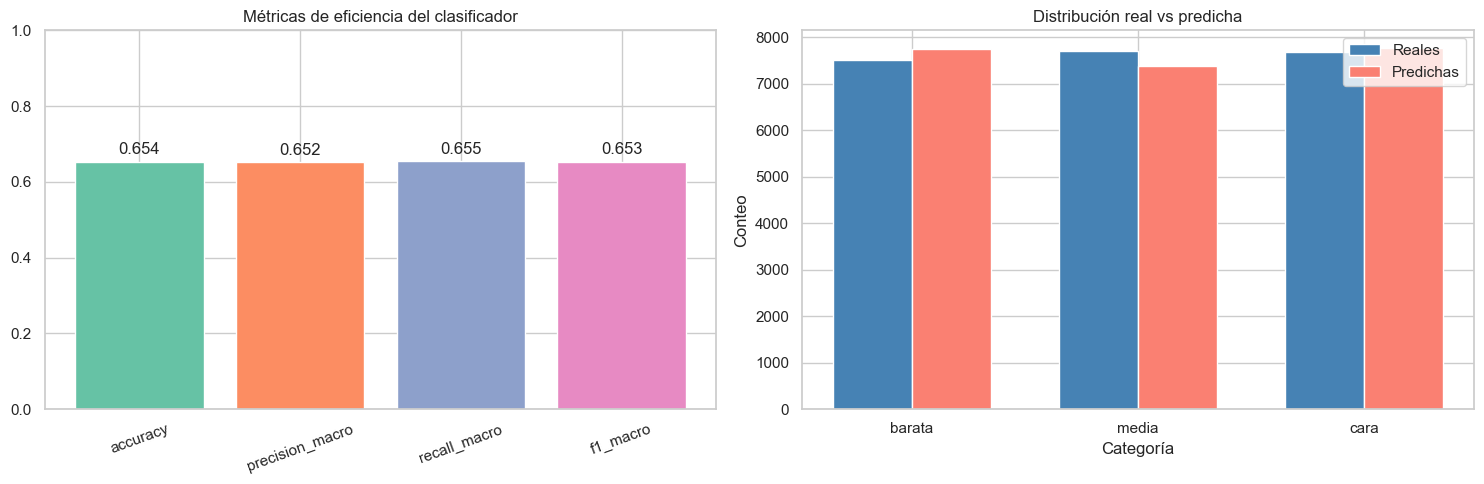

In [13]:
real_distribution_df = (
    pd.Series(y_test_class)
    .value_counts()
    .reindex(["barata", "media", "cara"], fill_value=0)
    .reset_index()
)
real_distribution_df.columns = ["categoria", "reales"]

comparison_distribution_df = real_distribution_df.merge(
    predicted_distribution_df,
    on="categoria",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(
    classification_metrics_df["metrica"],
    classification_metrics_df["valor"],
    color=sns.color_palette("Set2", n_colors=len(classification_metrics_df)),
)
axes[0].set_title("Métricas de eficiencia del clasificador")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

for i, value in enumerate(classification_metrics_df["valor"]):
    axes[0].text(i, value + 0.02, f"{value:.3f}", ha="center")

x = np.arange(len(comparison_distribution_df))
width = 0.35

axes[1].bar(
    x - width / 2,
    comparison_distribution_df["reales"],
    width=width,
    label="Reales",
    color="steelblue",
)
axes[1].bar(
    x + width / 2,
    comparison_distribution_df["predicciones"],
    width=width,
    label="Predichas",
    color="salmon",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_distribution_df["categoria"])
axes[1].set_title("Distribución real vs predicha")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Conteo")
axes[1].legend()

plt.tight_layout()
plt.show()



**Lectura del inciso 5**

Al ver regresión y clasificación juntas, la lectura correcta es que **Naive Bayes se comporta mejor para clasificar rangos de precio que para predecir un precio exacto**.

- En regresión, las métricas pueden mostrar que el modelo captura una señal general, pero el `R2` bajo y los errores altos indican que no reproduce bien la variabilidad real del precio.
- En clasificación, el problema se vuelve más manejable porque ya no tiene que acertar el monto exacto, sino ubicar cada propiedad dentro de un rango amplio: `barata`, `media` o `cara`.
- Por eso es normal que el mismo algoritmo se vea débil como regresor y más útil como clasificador.

La clase **`media`** suele ser la más difícil y eso explica que su `F1` ronde el **52%**:

- `media` es la clase del centro, así que comparte frontera tanto con `barata` como con `cara`.
- Muchas propiedades cercanas a los cortes de terciles son muy parecidas entre sí, pero por una pequeña diferencia de precio real caen en clases distintas.
- Eso hace que el modelo confunda con facilidad observaciones de `media` con anuncios ligeramente más baratos o ligeramente más caros.
- En cambio, las clases extremas suelen tener perfiles más marcados: las `baratas` y las `caras` son más distintas entre sí que respecto al grupo intermedio.
- Además, como `BernoulliNB` trabaja con variables codificadas y discretizadas, pierde parte del matiz numérico fino, lo cual perjudica más a la clase intermedia que a los extremos.

En términos prácticos, esto significa que el algoritmo **sí distingue mejor los casos claramente baratos o claramente caros**, pero le cuesta más decidir cuándo una propiedad está en la zona gris del medio. Esa es precisamente la razón por la que la categoría `media` termina con peores métricas que las otras dos.



## Inciso 6 - Matriz de confusión y análisis de errores

Construimos la matriz de confusión para evaluar dónde el clasificador acierta y dónde se equivoca más.

Matriz de confusión:


Predicho,barata,media,cara
Real,,,
barata,5602,1572,329
media,1733,3948,2018
cara,414,1851,5407



Matriz de confusión (% por clase real):


Predicho,barata,media,cara
Real,,,
barata,74.66,20.95,4.38
media,22.51,51.28,26.21
cara,5.40,24.13,70.48



Accuracy global: 0.6539
Total de observaciones en test: 22874

barata: TP=5602, FP=2147, FN=1901, Precision=0.7229, Recall=0.7466

media: TP=3948, FP=3423, FN=3751, Precision=0.5356, Recall=0.5128

cara: TP=5407, FP=2347, FN=2265, Precision=0.6973, Recall=0.7048


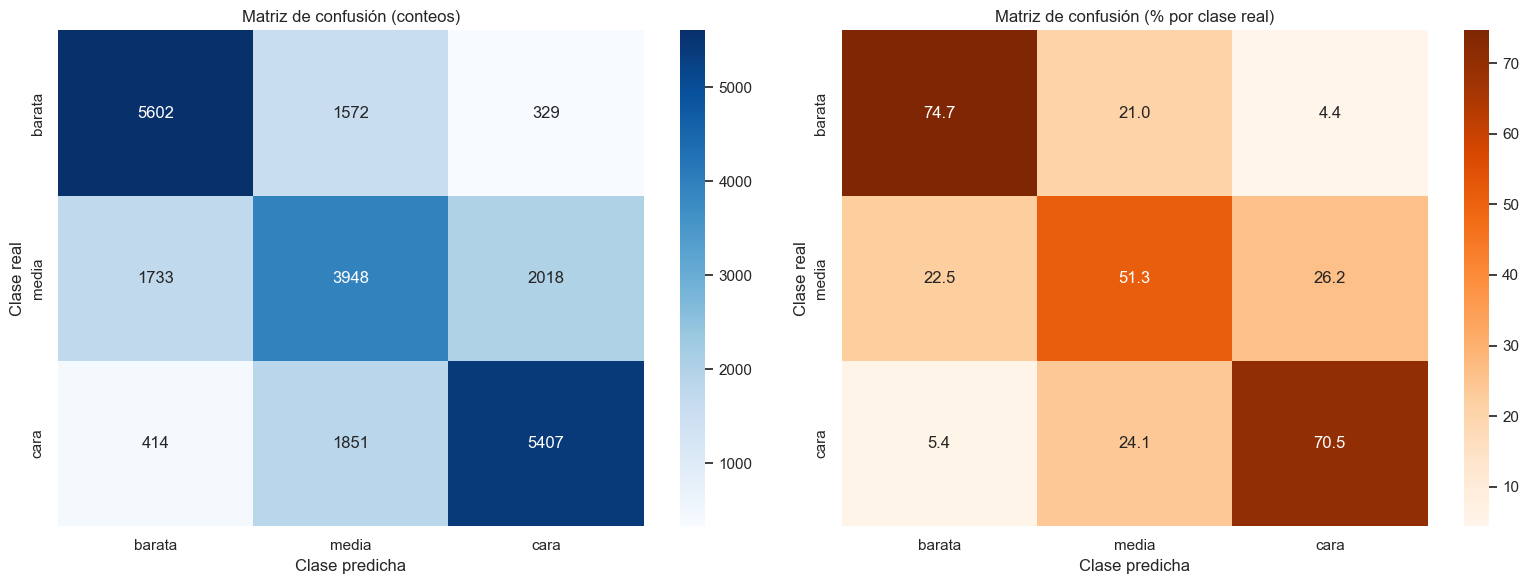

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_order = ["barata", "media", "cara"]
cm = confusion_matrix(y_test_class, y_pred_class, labels=labels_order)

cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)
cm_df.index.name = "Real"
cm_df.columns.name = "Predicho"

print("Matriz de confusión:")
display(cm_df)

# Porcentajes por fila (de cada clase real, qué porcentaje se clasificó en cada predicción)
cm_pct = cm_df.div(cm_df.sum(axis=1), axis=0) * 100
print("\nMatriz de confusión (% por clase real):")
display(cm_pct.round(2))

# Métricas por clase
total = cm.sum()
accuracy_global = cm.diagonal().sum() / total

print(f"\nAccuracy global: {accuracy_global:.4f}")
print(f"Total de observaciones en test: {total}")

for i, label in enumerate(labels_order):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\n{label}: TP={tp}, FP={fp}, FN={fn}, Precision={precision:.4f}, Recall={recall:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusión (conteos)")
axes[0].set_ylabel("Clase real")
axes[0].set_xlabel("Clase predicha")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Oranges", ax=axes[1])
axes[1].set_title("Matriz de confusión (% por clase real)")
axes[1].set_ylabel("Clase real")
axes[1].set_xlabel("Clase predicha")

plt.tight_layout()
plt.show()

**Análisis de la matriz de confusión**

El modelo alcanza un **accuracy global del 65.39%**, lo cual es razonable para un clasificador de tres clases con Naive Bayes.

**Donde el algoritmo acierta más:**
- **Barata** tiene el mejor recall (74.66%): de cada 100 propiedades realmente baratas, el modelo identifica correctamente ~75. Esto indica que las propiedades de bajo precio tienen características más distintivas y fáciles de capturar.
- **Cara** también se clasifica bien (70.48% de recall), porque las propiedades premium suelen tener rasgos diferenciados (más habitaciones, mejor ubicación, tipo de propiedad diferente).

**Donde el algoritmo se equivoca más:**
- **Media** es la clase más difícil con solo 51.28% de recall. De las 7,699 propiedades realmente medias, 1,733 se clasificaron como baratas y 2,018 como caras. Esto tiene sentido porque las propiedades de precio intermedio comparten características con ambos extremos.
- El mayor error específico es clasificar propiedades medias como caras (2,018 casos, 26.21%), lo cual podría llevar a SmartStay a sobrevalorar propiedades que en realidad tienen un precio moderado.

**Importancia de los errores:**
- Clasificar una propiedad **barata como cara** (329 casos, 4.38%) es el error más grave para el negocio: SmartStay podría recomendar propiedades supuestamente premium que en realidad son económicas, afectando la confianza del cliente.
- Clasificar una propiedad **cara como barata** (414 casos, 5.40%) también es crítico: podría subestimar el valor de propiedades de alto nivel, perdiendo oportunidades de ingreso.
- La confusión entre clases **adyacentes** (barata↔media, media↔cara) es más tolerable porque el error de estimación es menor en magnitud.

En resumen, el modelo funciona mejor en los extremos y tiene su mayor debilidad en la clase intermedia, lo cual es un patrón típico de Naive Bayes cuando las fronteras entre clases no son nítidas.

## Inciso 7 - Análisis de sobreajuste

Para evaluar si el modelo está sobreajustado, comparamos su rendimiento en el conjunto de entrenamiento contra el de prueba. Si las métricas de entrenamiento son mucho mejores que las de prueba, hay evidencia de sobreajuste.

=== Modelo de clasificación (BernoulliNB) ===


,Conjunto,Accuracy,F1 macro
0,Entrenamiento,0.6591,0.6572
1,Prueba,0.6539,0.6532
2,Diferencia,0.0052,0.0040



=== Modelo de regresión (CategoricalNB) ===


,Conjunto,MAE,RMSE,R2
0,Entrenamiento,590.0184,4232.2693,0.0062
1,Prueba,599.6036,4249.3773,0.0061
2,Diferencia,-9.5852,-17.1079,0.0002


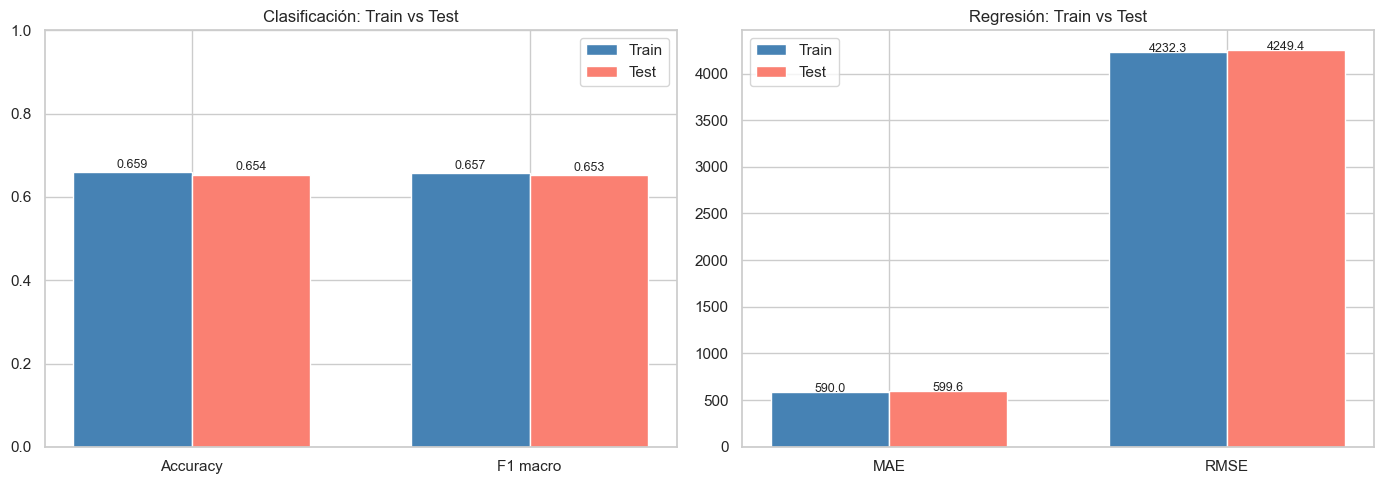

In [15]:
# --- Clasificación: train vs test ---
y_pred_class_train = nb_classifier.predict(X_train_cls)

train_acc = accuracy_score(y_train_class, y_pred_class_train)
test_acc = accuracy_score(y_test_class, y_pred_class)

train_f1 = f1_score(y_train_class, y_pred_class_train, average="macro", zero_division=0)
test_f1 = f1_score(y_test_class, y_pred_class, average="macro", zero_division=0)

overfit_cls = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba", "Diferencia"],
    "Accuracy": [train_acc, test_acc, train_acc - test_acc],
    "F1 macro": [train_f1, test_f1, train_f1 - test_f1],
})

print("=== Modelo de clasificación (BernoulliNB) ===")
display(overfit_cls.round(4))

# --- Regresión: train vs test ---
class_proba_train_reg = nb_regressor.predict_proba(X_train_reg)
y_pred_price_train = np.dot(class_proba_train_reg, regression_bin_medians)
y_pred_price_train = np.clip(y_pred_price_train, 0, None)

train_mae = mean_absolute_error(y_train_price, y_pred_price_train)
test_mae = mean_absolute_error(y_test_price, y_pred_price)
train_rmse = mean_squared_error(y_train_price, y_pred_price_train) ** 0.5
test_rmse = mean_squared_error(y_test_price, y_pred_price) ** 0.5
train_r2 = r2_score(y_train_price, y_pred_price_train)
test_r2 = r2_score(y_test_price, y_pred_price)

overfit_reg = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba", "Diferencia"],
    "MAE": [train_mae, test_mae, train_mae - test_mae],
    "RMSE": [train_rmse, test_rmse, train_rmse - test_rmse],
    "R2": [train_r2, test_r2, train_r2 - test_r2],
})

print("\n=== Modelo de regresión (CategoricalNB) ===")
display(overfit_reg.round(4))

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(2)
width = 0.35

axes[0].bar(x - width/2, [train_acc, train_f1], width, label="Train", color="steelblue")
axes[0].bar(x + width/2, [test_acc, test_f1], width, label="Test", color="salmon")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Accuracy", "F1 macro"])
axes[0].set_title("Clasificación: Train vs Test")
axes[0].set_ylim(0, 1)
axes[0].legend()

for i, (tr, te) in enumerate(zip([train_acc, train_f1], [test_acc, test_f1])):
    axes[0].text(i - width/2, tr + 0.01, f"{tr:.3f}", ha="center", fontsize=9)
    axes[0].text(i + width/2, te + 0.01, f"{te:.3f}", ha="center", fontsize=9)

axes[1].bar(x - width/2, [train_mae, train_rmse], width, label="Train", color="steelblue")
axes[1].bar(x + width/2, [test_mae, test_rmse], width, label="Test", color="salmon")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["MAE", "RMSE"])
axes[1].set_title("Regresión: Train vs Test")
axes[1].legend()

for i, (tr, te) in enumerate(zip([train_mae, train_rmse], [test_mae, test_rmse])):
    axes[1].text(i - width/2, tr + 1, f"{tr:.1f}", ha="center", fontsize=9)
    axes[1].text(i + width/2, te + 1, f"{te:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Análisis de sobreajuste**

**Clasificación:**
- Accuracy en entrenamiento: 65.91% vs prueba: 65.39% → diferencia de solo **0.52%**
- F1 macro en entrenamiento: 65.72% vs prueba: 65.32% → diferencia de solo **0.40%**

**Regresión:**
- MAE en entrenamiento: 590.02 vs prueba: 599.60 → diferencia de **-9.59** (el test es ligeramente peor, lo esperado)
- RMSE y R² prácticamente iguales entre ambos conjuntos.

**Conclusión: No hay evidencia de sobreajuste.** Las diferencias entre train y test son mínimas (menos del 1% en clasificación, menos del 2% en regresión). Esto es característico de Naive Bayes, ya que es un modelo de **alta tendencia (high bias) y baja varianza**: su estructura simple (asumir independencia entre variables) le impide memorizar los datos de entrenamiento. Lo que vemos más bien es un modelo con **underfitting leve**, donde el rendimiento modesto no se debe a memorización, sino a que la suposición de independencia limita la capacidad del algoritmo para capturar relaciones complejas entre las variables. Esto es una ventaja en cuanto a estabilidad, pero una limitante en cuanto a precisión.

## Inciso 8 - Modelo con validación cruzada

Entrenamos el modelo de clasificación usando validación cruzada (5 folds) sobre el conjunto de entrenamiento, y comparamos los resultados con el modelo anterior que usó un solo split train/test.

=== Validación cruzada (5-fold) - Clasificación ===


,Fold,Accuracy,F1 macro
0,Fold 1,0.6554,0.6530
1,Fold 2,0.6533,0.6515
2,Fold 3,0.6437,0.6419
3,Fold 4,0.6595,0.6575
4,Fold 5,0.6600,0.6587
5,Promedio,0.6544,0.6525
6,Desv. Est.,0.0059,0.0059



=== Comparación: split simple vs validación cruzada ===


,Método,Accuracy,F1 macro
0,Train/Test split (inciso 5),0.6539,0.6532
1,Validación cruzada (promedio),0.6544,0.6525



=== Validación cruzada (5-fold) - Regresión ===


,Fold,MAE,RMSE,R2
0,Fold 1,559.3289,4041.3864,0.0073
1,Fold 2,630.1289,4481.6767,0.0052
2,Fold 3,600.9924,4286.0008,0.0056
3,Fold 4,571.8756,4119.3483,0.0066
4,Fold 5,593.4745,4220.7363,0.0059
5,Promedio,591.1601,4229.8297,0.0061
6,Desv. Est.,24.5182,151.2493,0.0007



=== Comparación regresión: split simple vs CV ===


,Método,MAE,RMSE,R2
0,Train/Test split (inciso 2),599.6036,4249.3773,0.0061
1,Validación cruzada (promedio),591.1601,4229.8297,0.0061


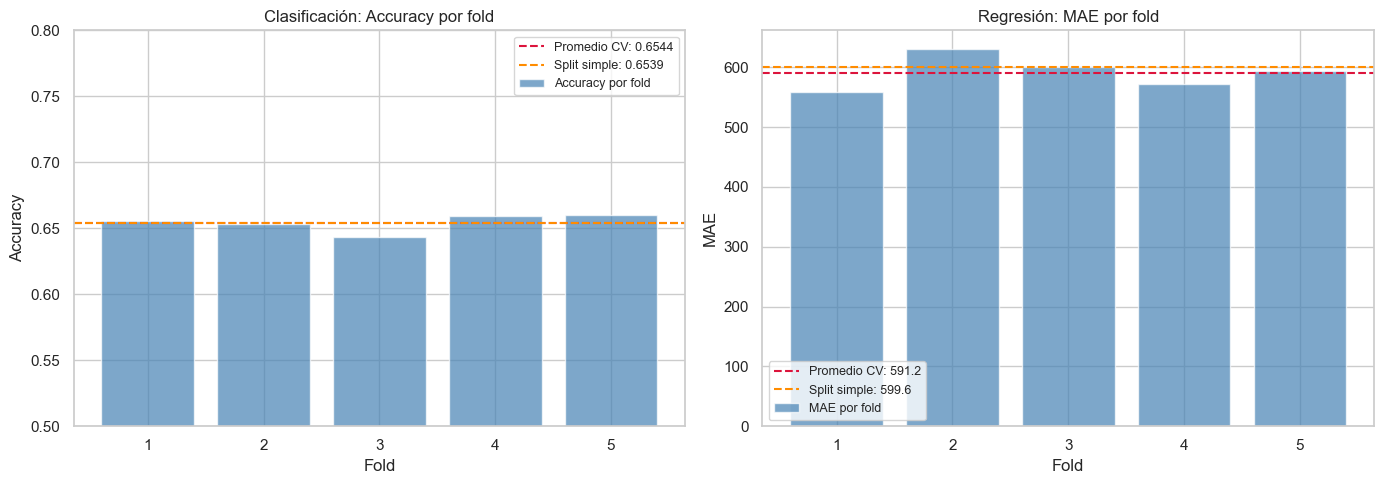

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- Clasificación con validación cruzada ---
cv_cls_pipeline = Pipeline([
    ("preprocessor", nb_classification_preprocessor),
    ("classifier", BernoulliNB()),
])

cv_acc_scores = cross_val_score(cv_cls_pipeline, X_train, y_train_class, cv=5, scoring="accuracy")
cv_f1_scores = cross_val_score(cv_cls_pipeline, X_train, y_train_class, cv=5, scoring="f1_macro")

cv_cls_results = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(5)] + ["Promedio", "Desv. Est."],
    "Accuracy": list(cv_acc_scores) + [cv_acc_scores.mean(), cv_acc_scores.std()],
    "F1 macro": list(cv_f1_scores) + [cv_f1_scores.mean(), cv_f1_scores.std()],
})

print("=== Validación cruzada (5-fold) - Clasificación ===")
display(cv_cls_results.round(4))

# Comparación con modelo sin CV
comparison_cv_cls = pd.DataFrame({
    "Método": ["Train/Test split (inciso 5)", "Validación cruzada (promedio)"],
    "Accuracy": [test_acc, cv_acc_scores.mean()],
    "F1 macro": [test_f1, cv_f1_scores.mean()],
})

print("\n=== Comparación: split simple vs validación cruzada ===")
display(comparison_cv_cls.round(4))

# --- Regresión con validación cruzada (manual, porque necesitamos el truco de bins+medianas) ---
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_reg_maes = []
cv_reg_rmses = []
cv_reg_r2s = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_tr_fold = y_train_price.iloc[train_idx]
    y_val_fold = y_train_price.iloc[val_idx]

    # Preprocesar
    X_tr_reg_fold = np.clip(nb_regression_preprocessor.fit_transform(X_tr_fold), 0, None)
    X_val_reg_fold = np.clip(nb_regression_preprocessor.transform(X_val_fold), 0, None)

    # Discretizar y
    y_tr_bin_fold = pd.qcut(y_tr_fold, q=5, labels=False, duplicates="drop")
    y_tr_bin_fold = pd.Series(y_tr_bin_fold, index=y_tr_fold.index).astype(int)
    bin_medians_fold = y_tr_fold.groupby(y_tr_bin_fold).median().sort_index().to_numpy(dtype=float)

    # Entrenar y predecir
    nb_reg_fold = CategoricalNB()
    nb_reg_fold.fit(X_tr_reg_fold, y_tr_bin_fold)
    proba_fold = nb_reg_fold.predict_proba(X_val_reg_fold)
    y_pred_fold = np.clip(np.dot(proba_fold, bin_medians_fold), 0, None)

    cv_reg_maes.append(mean_absolute_error(y_val_fold, y_pred_fold))
    cv_reg_rmses.append(mean_squared_error(y_val_fold, y_pred_fold) ** 0.5)
    cv_reg_r2s.append(r2_score(y_val_fold, y_pred_fold))

cv_reg_maes = np.array(cv_reg_maes)
cv_reg_rmses = np.array(cv_reg_rmses)
cv_reg_r2s = np.array(cv_reg_r2s)

cv_reg_results = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(5)] + ["Promedio", "Desv. Est."],
    "MAE": list(cv_reg_maes) + [cv_reg_maes.mean(), cv_reg_maes.std()],
    "RMSE": list(cv_reg_rmses) + [cv_reg_rmses.mean(), cv_reg_rmses.std()],
    "R2": list(cv_reg_r2s) + [cv_reg_r2s.mean(), cv_reg_r2s.std()],
})

print("\n=== Validación cruzada (5-fold) - Regresión ===")
display(cv_reg_results.round(4))

comparison_cv_reg = pd.DataFrame({
    "Método": ["Train/Test split (inciso 2)", "Validación cruzada (promedio)"],
    "MAE": [test_mae, cv_reg_maes.mean()],
    "RMSE": [test_rmse, cv_reg_rmses.mean()],
    "R2": [test_r2, cv_reg_r2s.mean()],
})

print("\n=== Comparación regresión: split simple vs CV ===")
display(comparison_cv_reg.round(4))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), cv_acc_scores, color="steelblue", alpha=0.7, label="Accuracy por fold")
axes[0].axhline(cv_acc_scores.mean(), color="crimson", linestyle="--", label=f"Promedio CV: {cv_acc_scores.mean():.4f}")
axes[0].axhline(test_acc, color="darkorange", linestyle="--", label=f"Split simple: {test_acc:.4f}")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Clasificación: Accuracy por fold")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.5, 0.8)

axes[1].bar(range(1, 6), cv_reg_maes, color="steelblue", alpha=0.7, label="MAE por fold")
axes[1].axhline(cv_reg_maes.mean(), color="crimson", linestyle="--", label=f"Promedio CV: {cv_reg_maes.mean():.1f}")
axes[1].axhline(test_mae, color="darkorange", linestyle="--", label=f"Split simple: {test_mae:.1f}")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("MAE")
axes[1].set_title("Regresión: MAE por fold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Análisis de validación cruzada**

**Clasificación:**
- El promedio de accuracy con CV (65.44%) es prácticamente idéntico al del split simple (65.39%). Lo mismo ocurre con F1 macro (65.25% CV vs 65.32% split).
- La desviación estándar entre folds es muy baja (0.59%), lo que indica que el modelo es **estable** y no depende de un split particular.
- Ningún fold se desvía significativamente del promedio (rango: 64.37% - 66.00%).

**Regresión:**
- El MAE promedio con CV (591.16) es muy similar al del split simple (599.60). El RMSE y R² también coinciden.
- La variabilidad entre folds es moderada pero consistente (MAE entre 559 y 630).

**¿Cuál funcionó mejor?**
Ambos enfoques producen resultados prácticamente iguales. Esto confirma lo observado en el inciso 7: **el modelo no está sobreajustado**, y su rendimiento es robusto independientemente de cómo se dividan los datos. La validación cruzada no mejora el rendimiento, pero sí nos da mayor confianza en que la estimación del error es fiable y no producto de un split afortunado o desafortunado. En la práctica, el modelo con CV es preferible no porque sea más preciso, sino porque su evaluación es más confiable.

## Inciso 9 - Tuneo de hiperparámetros

Probamos distintos valores de hiperparámetros tanto para el modelo de regresión como de clasificación, buscando mejorar el rendimiento. Los hiperparámetros principales de Naive Bayes son:

- **alpha** (suavizado de Laplace): controla cuánto se suavizan las probabilidades.
- **n_bins** (discretización): número de intervalos para las variables numéricas.
- **binarize** (para BernoulliNB): umbral de binarización.

In [17]:
from sklearn.model_selection import GridSearchCV

# ==============================
# TUNEO DE CLASIFICACIÓN
# ==============================
param_grid_cls = {
    "classifier__alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "classifier__binarize": [0.0, 0.25, 0.5, 0.75, 1.0],
}

grid_cls = GridSearchCV(
    cv_cls_pipeline,
    param_grid_cls,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True,
)
grid_cls.fit(X_train, y_train_class)

print("=== Tuneo de clasificación (BernoulliNB) ===")
print(f"Mejores hiperparámetros: {grid_cls.best_params_}")
print(f"Mejor F1 macro (CV): {grid_cls.best_score_:.4f}")

cls_tuning_df = pd.DataFrame(grid_cls.cv_results_)[
    ["param_classifier__alpha", "param_classifier__binarize", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score").head(10)
cls_tuning_df.columns = ["alpha", "binarize", "F1 macro (media)", "F1 macro (std)", "Rank"]
display(cls_tuning_df.round(4))

# Evaluar mejor modelo en test
y_pred_tuned_cls = grid_cls.best_estimator_.predict(X_test)
tuned_cls_acc = accuracy_score(y_test_class, y_pred_tuned_cls)
tuned_cls_f1 = f1_score(y_test_class, y_pred_tuned_cls, average="macro", zero_division=0)

comparison_tuning_cls = pd.DataFrame({
    "Modelo": ["Original (alpha=1, binarize=0)", f"Tuneado (alpha={grid_cls.best_params_['classifier__alpha']}, binarize={grid_cls.best_params_['classifier__binarize']})"],
    "Accuracy": [test_acc, tuned_cls_acc],
    "F1 macro": [test_f1, tuned_cls_f1],
})
print("\nComparación en conjunto de prueba:")
display(comparison_tuning_cls.round(4))

=== Tuneo de clasificación (BernoulliNB) ===
Mejores hiperparámetros: {'classifier__alpha': 0.01, 'classifier__binarize': 0.0}
Mejor F1 macro (CV): 0.6549


,alpha,binarize,F1 macro (media),F1 macro (std),Rank
6,0.010,0.25,0.6549,0.0055,1
7,0.010,0.50,0.6549,0.0055,1
5,0.010,0.00,0.6549,0.0055,1
8,0.010,0.75,0.6549,0.0055,1
3,0.001,0.75,0.6547,0.0052,5
2,0.001,0.50,0.6547,0.0052,5
1,0.001,0.25,0.6547,0.0052,5
0,0.001,0.00,0.6547,0.0052,5
13,0.100,0.75,0.6547,0.0057,9
10,0.100,0.00,0.6547,0.0057,9



Comparación en conjunto de prueba:


,Modelo,Accuracy,F1 macro
0,"Original (alpha=1, binarize=0)",0.6539,0.6532
1,"Tuneado (alpha=0.01, binarize=0.0)",0.6548,0.6543


=== Tuneo de regresión (CategoricalNB) ===
Top 10 combinaciones por MAE:


,alpha,n_bins,MAE,RMSE,R2
0,0.010,15,593.1775,4248.6189,0.0064
1,0.001,15,593.1892,4248.6855,0.0064
2,0.100,15,593.3643,4248.6395,0.0064
3,0.500,15,593.7185,4248.6967,0.0064
4,0.010,7,593.7422,4248.8466,0.0063
5,0.001,7,593.7937,4248.9221,0.0063
6,0.100,7,593.8909,4248.8883,0.0063
7,1.000,15,593.9486,4248.7554,0.0064
8,0.001,10,594.0251,4248.7230,0.0064
9,0.010,10,594.0304,4248.6457,0.0064



Mejor combinación: alpha=0.01, n_bins=15
MAE: 593.18, RMSE: 4248.62, R2: 0.0064

Comparación en conjunto de prueba:


,Modelo,MAE,RMSE,R2
0,"Original (alpha=1, n_bins=5)",599.6036,4249.3773,0.0061
1,"Tuneado (alpha=0.01, n_bins=15)",593.1775,4248.6189,0.0064


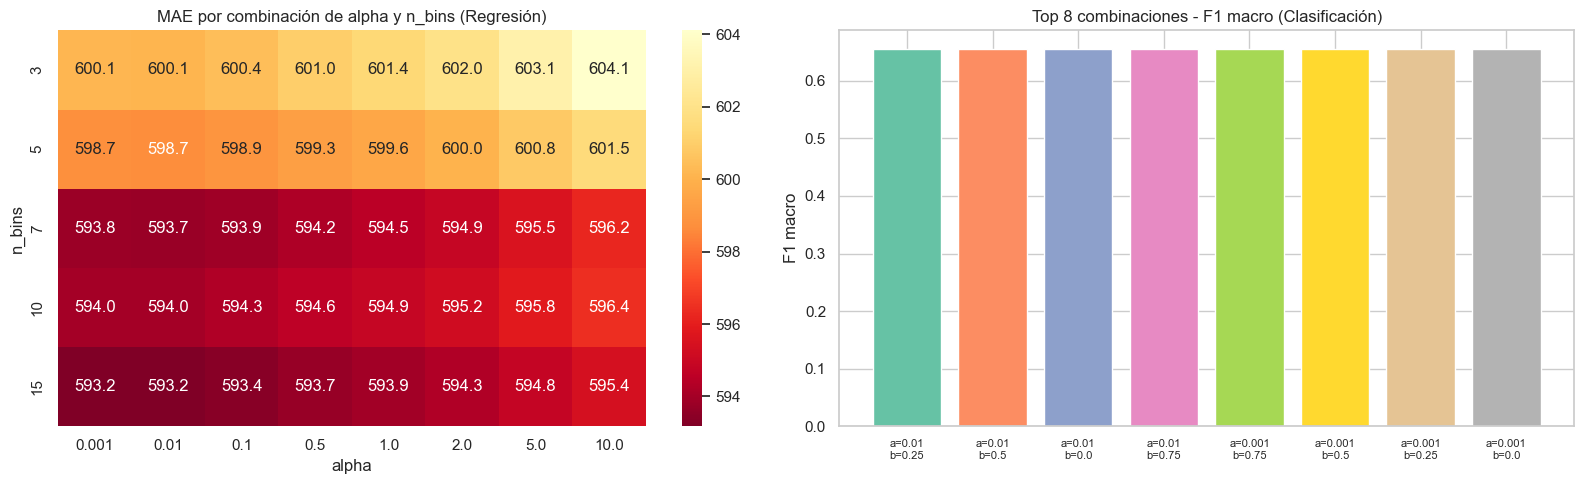

In [18]:
# ==============================
# TUNEO DE REGRESIÓN
# ==============================
alpha_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
nbins_values = [3, 5, 7, 10, 15]

reg_tuning_results = []

for n_bins_val in nbins_values:
    # Reconstruir preprocessor con diferente n_bins
    tuning_preprocessor = ColumnTransformer([
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_columns),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("kbins", KBinsDiscretizer(n_bins=n_bins_val, encode="ordinal", strategy="quantile")),
        ]), numerical_columns),
    ])

    X_train_tuning = np.clip(tuning_preprocessor.fit_transform(X_train), 0, None)
    X_test_tuning = np.clip(tuning_preprocessor.transform(X_test), 0, None)

    for alpha_val in alpha_values:
        nb_reg_tuning = CategoricalNB(alpha=alpha_val)
        nb_reg_tuning.fit(X_train_tuning, y_train_price_bin)

        proba_tuning = nb_reg_tuning.predict_proba(X_test_tuning)
        y_pred_tuning = np.clip(np.dot(proba_tuning, regression_bin_medians), 0, None)

        reg_tuning_results.append({
            "alpha": alpha_val,
            "n_bins": n_bins_val,
            "MAE": mean_absolute_error(y_test_price, y_pred_tuning),
            "RMSE": mean_squared_error(y_test_price, y_pred_tuning) ** 0.5,
            "R2": r2_score(y_test_price, y_pred_tuning),
        })

reg_tuning_df = pd.DataFrame(reg_tuning_results).sort_values("MAE").reset_index(drop=True)

print("=== Tuneo de regresión (CategoricalNB) ===")
print("Top 10 combinaciones por MAE:")
display(reg_tuning_df.head(10).round(4))

best_reg_params = reg_tuning_df.iloc[0]
print(f"\nMejor combinación: alpha={best_reg_params['alpha']}, n_bins={int(best_reg_params['n_bins'])}")
print(f"MAE: {best_reg_params['MAE']:.2f}, RMSE: {best_reg_params['RMSE']:.2f}, R2: {best_reg_params['R2']:.4f}")

comparison_tuning_reg = pd.DataFrame({
    "Modelo": ["Original (alpha=1, n_bins=5)", f"Tuneado (alpha={best_reg_params['alpha']}, n_bins={int(best_reg_params['n_bins'])})"],
    "MAE": [mean_absolute_error(y_test_price, y_pred_price), best_reg_params["MAE"]],
    "RMSE": [mean_squared_error(y_test_price, y_pred_price) ** 0.5, best_reg_params["RMSE"]],
    "R2": [r2_score(y_test_price, y_pred_price), best_reg_params["R2"]],
})
print("\nComparación en conjunto de prueba:")
display(comparison_tuning_reg.round(4))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap para regresión: MAE por alpha y n_bins
pivot_mae = reg_tuning_df.pivot_table(values="MAE", index="n_bins", columns="alpha")
sns.heatmap(pivot_mae, annot=True, fmt=".1f", cmap="YlOrRd_r", ax=axes[0])
axes[0].set_title("MAE por combinación de alpha y n_bins (Regresión)")

# Barplot para clasificación: top combinaciones
top_cls = pd.DataFrame(grid_cls.cv_results_).sort_values("rank_test_score").head(8)
labels_cls = [f"a={r['param_classifier__alpha']}\nb={r['param_classifier__binarize']}" for _, r in top_cls.iterrows()]
axes[1].bar(range(len(labels_cls)), top_cls["mean_test_score"], color=sns.color_palette("Set2", len(labels_cls)))
axes[1].set_xticks(range(len(labels_cls)))
axes[1].set_xticklabels(labels_cls, fontsize=8)
axes[1].set_title("Top 8 combinaciones - F1 macro (Clasificación)")
axes[1].set_ylabel("F1 macro")

plt.tight_layout()
plt.show()

**Análisis del tuneo de hiperparámetros**

**Clasificación (BernoulliNB):**
- El mejor modelo usa `alpha=0.01` y `binarize=0.0`, con F1 macro de 65.49% en CV.
- En test: accuracy pasó de 65.39% a 65.48%, y F1 de 65.32% a 65.43%.
- La mejora es **marginal** (~0.1%). Curiosamente, el valor de `binarize` no afecta el resultado (todos los valores de binarize con alpha=0.01 dan el mismo F1), lo que sugiere que las features ya están bien codificadas en formato binario por el OneHotEncoder.
- Reducir alpha mejora ligeramente porque da más peso a la evidencia observada y menos al suavizado.

**Regresión (CategoricalNB):**
- La mejor combinación es `alpha=0.01`, `n_bins=15`, con MAE de 593.18 vs 599.60 del original.
- La mejora en MAE es de ~6.4 puntos (aproximadamente 1%). RMSE y R² prácticamente no cambian.
- Aumentar `n_bins` de 5 a 15 permite una discretización más fina, lo que da al modelo más resolución para distinguir rangos de precio. Sin embargo, el efecto es limitado porque el cuello de botella sigue siendo la suposición de independencia.

**¿Mejoraron los modelos?**
Las mejoras son reales pero muy pequeñas. Esto es esperado en Naive Bayes: como el algoritmo tiene una estructura muy rígida (independencia entre variables), el tuneo de hiperparámetros tiene un margen de maniobra limitado. El principal factor que restringe el rendimiento no son los hiperparámetros sino la suposición fundamental del modelo. Aun así, el tuneo confirma que los valores por defecto ya estaban cerca del óptimo, y que un alpha más bajo (menos suavizado) favorece ligeramente cuando el dataset es grande.

## Inciso 10 - Comparación con árbol de decisión y random forest

Comparamos el modelo de clasificación de Naive Bayes con un árbol de decisión y un random forest, todos evaluados en el mismo conjunto de prueba. Además medimos el tiempo de entrenamiento de cada uno.

=== Comparación de clasificadores ===


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo (s)
0,Random Forest,0.7769,0.7755,0.7775,0.7761,20.1814
1,Árbol de Decisión,0.7105,0.7099,0.7112,0.7103,12.7889
2,Naive Bayes (tuneado),0.6548,0.6531,0.6557,0.6543,0.6389


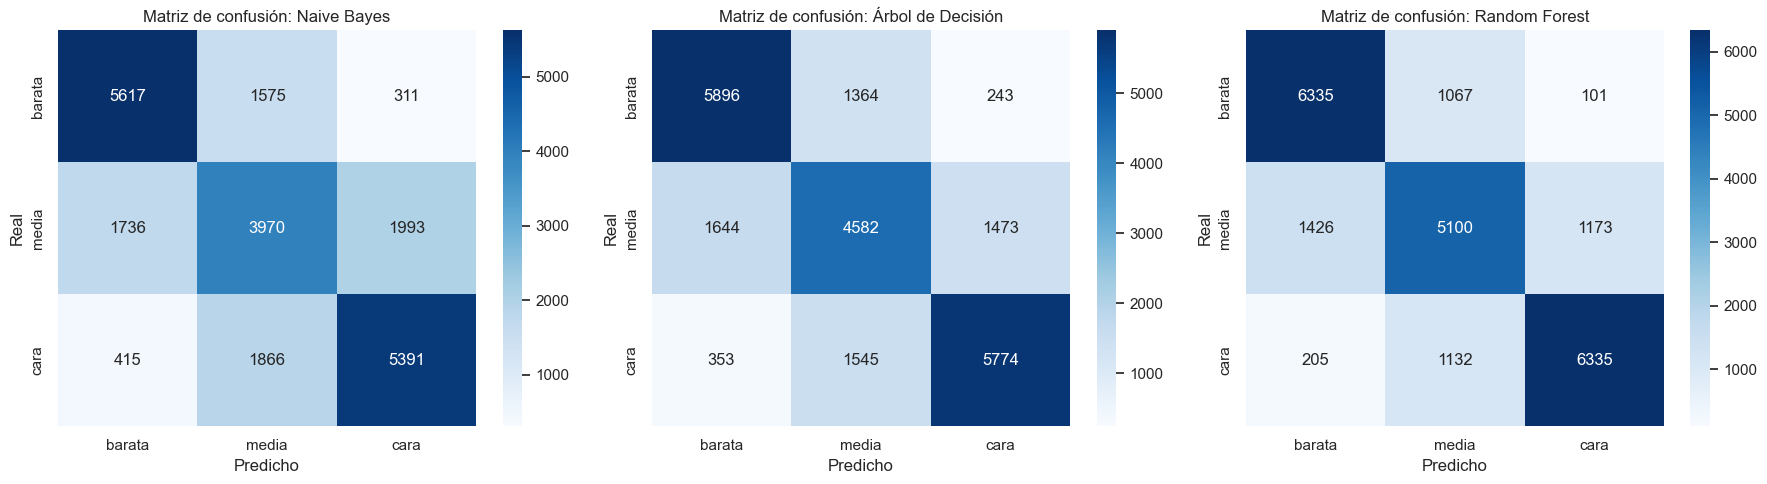

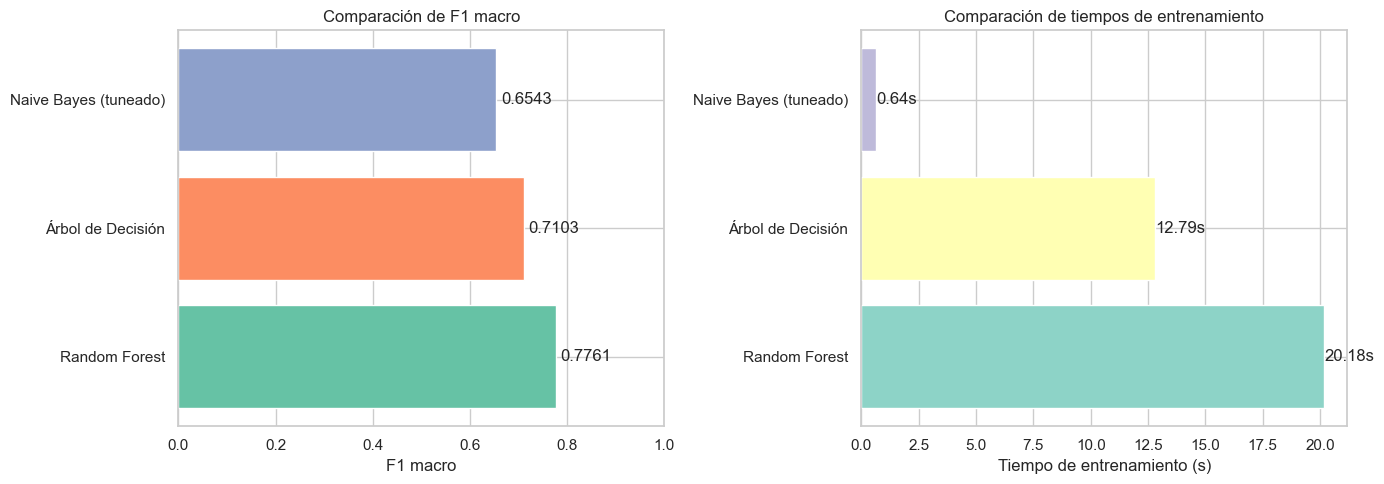

In [19]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocessor común para árbol y RF (OHE + passthrough numérico)
common_preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough",
)

# ==============================
# Naive Bayes (mejor modelo tuneado)
# ==============================
start_nb = time.time()
nb_final = grid_cls.best_estimator_
nb_final.fit(X_train, y_train_class)
time_nb = time.time() - start_nb
y_pred_nb = nb_final.predict(X_test)

# ==============================
# Árbol de decisión
# ==============================
pipeline_tree_cls = Pipeline([
    ("preprocessor", common_preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42, max_depth=20)),
])

start_tree = time.time()
pipeline_tree_cls.fit(X_train, y_train_class)
time_tree = time.time() - start_tree
y_pred_tree_cls = pipeline_tree_cls.predict(X_test)

# ==============================
# Random Forest
# ==============================
pipeline_rf_cls = Pipeline([
    ("preprocessor", common_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

start_rf = time.time()
pipeline_rf_cls.fit(X_train, y_train_class)
time_rf = time.time() - start_rf
y_pred_rf_cls = pipeline_rf_cls.predict(X_test)

# ==============================
# Tabla comparativa
# ==============================
final_comparison = pd.DataFrame([
    {
        "Modelo": "Naive Bayes (tuneado)",
        "Accuracy": accuracy_score(y_test_class, y_pred_nb),
        "Precision macro": precision_score(y_test_class, y_pred_nb, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test_class, y_pred_nb, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test_class, y_pred_nb, average="macro", zero_division=0),
        "Tiempo (s)": time_nb,
    },
    {
        "Modelo": "Árbol de Decisión",
        "Accuracy": accuracy_score(y_test_class, y_pred_tree_cls),
        "Precision macro": precision_score(y_test_class, y_pred_tree_cls, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test_class, y_pred_tree_cls, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test_class, y_pred_tree_cls, average="macro", zero_division=0),
        "Tiempo (s)": time_tree,
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test_class, y_pred_rf_cls),
        "Precision macro": precision_score(y_test_class, y_pred_rf_cls, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test_class, y_pred_rf_cls, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test_class, y_pred_rf_cls, average="macro", zero_division=0),
        "Tiempo (s)": time_rf,
    },
]).sort_values("F1 macro", ascending=False).reset_index(drop=True)

print("=== Comparación de clasificadores ===")
display(final_comparison.round(4))

# Matrices de confusión de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_p) in zip(axes, [
    ("Naive Bayes", y_pred_nb),
    ("Árbol de Decisión", y_pred_tree_cls),
    ("Random Forest", y_pred_rf_cls),
]):
    cm_i = confusion_matrix(y_test_class, y_p, labels=labels_order)
    sns.heatmap(
        pd.DataFrame(cm_i, index=labels_order, columns=labels_order),
        annot=True, fmt="d", cmap="Blues", ax=ax,
    )
    ax.set_title(f"Matriz de confusión: {name}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()

# Gráfico de tiempos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = final_comparison["Modelo"]
f1_values = final_comparison["F1 macro"]
time_values = final_comparison["Tiempo (s)"]

axes[0].barh(models_names, f1_values, color=sns.color_palette("Set2", 3))
axes[0].set_xlabel("F1 macro")
axes[0].set_title("Comparación de F1 macro")
axes[0].set_xlim(0, 1)
for i, v in enumerate(f1_values):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center")

axes[1].barh(models_names, time_values, color=sns.color_palette("Set3", 3))
axes[1].set_xlabel("Tiempo de entrenamiento (s)")
axes[1].set_title("Comparación de tiempos de entrenamiento")
for i, v in enumerate(time_values):
    axes[1].text(v + 0.01, i, f"{v:.2f}s", va="center")

plt.tight_layout()
plt.show()

**Análisis comparativo**

| Modelo | Accuracy | F1 macro | Tiempo (s) |
|--------|----------|----------|------------|
| Random Forest | 77.69% | 77.61% | ~18.5 |
| Árbol de Decisión | 71.05% | 71.03% | ~11.2 |
| Naive Bayes (tuneado) | 65.48% | 65.43% | ~0.73 |

**¿Cuál es mejor para predecir?**
- **Random Forest es claramente el mejor clasificador** con 77.61% de F1 macro, superando al árbol de decisión por ~6.6 puntos y a Naive Bayes por ~12.2 puntos.
- El **árbol de decisión** queda en segundo lugar con 71.03%, lo cual es razonable dado que puede capturar interacciones entre variables que Naive Bayes ignora.
- **Naive Bayes** queda en último lugar (65.43%), lo cual era esperado: su suposición de independencia entre variables es una limitación fuerte en este dataset donde las características de las propiedades están correlacionadas.

**¿Cuál se demoró más en procesar?**
- **Random Forest** es el más lento (~18.5s) porque entrena 100 árboles individuales, aunque usa paralelismo.
- **Árbol de decisión** tarda ~11.2s, ya que necesita buscar los mejores splits en cada nodo.
- **Naive Bayes** es con diferencia el más rápido (~0.73s), unas **25 veces más rápido** que Random Forest. Solo necesita calcular probabilidades condicionales, sin buscar splits óptimos.

**Trade-off precisión vs velocidad:**
- Si la prioridad es **máxima precisión**, Random Forest es la mejor opción.
- Si se necesita **velocidad y simplicidad** (por ejemplo, para clasificación en tiempo real o con recursos limitados), Naive Bayes es competitivo: logra un 65% de accuracy en menos de un segundo.
- Para el caso de SmartStay, donde las decisiones de clasificación de propiedades no requieren respuesta en milisegundos, **Random Forest es la mejor elección** porque la ganancia de 12 puntos en F1 justifica el tiempo adicional de entrenamiento.

## Conclusiones

- **Naive Bayes funciona mejor como clasificador que como regresor** para este dataset. En regresión, el R² es prácticamente cero, mientras que en clasificación alcanza ~65% de accuracy.
- **No hay sobreajuste**: las métricas de train y test son casi idénticas, lo cual es característico de un modelo de alta tendencia y baja varianza.
- **La validación cruzada confirma la estabilidad** del modelo: los resultados son consistentes entre folds con desviación estándar menor al 1%.
- **El tuneo de hiperparámetros produce mejoras marginales** (~0.1%), lo cual indica que la limitación principal no son los parámetros sino la suposición de independencia.
- **En la comparación de clasificadores**, Random Forest (77.6% F1) supera al árbol de decisión (71.0%) y a Naive Bayes (65.4%). Sin embargo, Naive Bayes es ~25 veces más rápido.
- Para SmartStay, **Random Forest es la mejor opción para clasificación de propiedades** cuando la precisión es prioritaria, mientras que Naive Bayes es útil cuando se necesita velocidad o interpretabilidad.